### Unet

Это симметричная сверточная нейронная сеть, созданная для семантической сегментации изображений, которая показывает высокую эффективность даже на небольших наборах данных

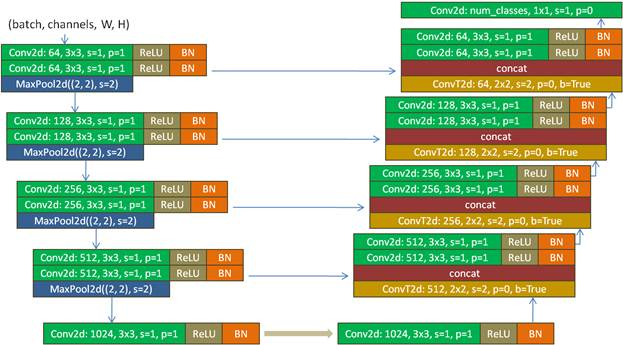

In [13]:
import torch
import torch.nn as nn

Создадим класс DoubleConv, потому что двойная свертка используется 9 раз

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, (3,3), padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, (3,3), padding=1)
        self.act = nn.ReLU()
    
    def forward(self,x):
        x = self.conv1(x)
        x = self.act(x)
        x = self.conv2(x)
        out = self.act(x)
        return out

Двойная свертка и MaxPooling используются 4 раза, поэтому создадим класс DownSawmple

In [15]:
class DownSample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.doubleconv = DoubleConv(in_ch, out_ch)
        self.maxpool = nn.MaxPool2d(2)

    def forward(self, x):
        out_doubleconv = self.doubleconv(x)
        out_maxpool = self.maxpool(out_doubleconv)
        return out_doubleconv, out_maxpool

2 сверточных слоя, конкатенация и транспонированная свертка используются 4 раза, поэтому создадим класс UpSample

In [16]:
class UpSample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.doubleconv = DoubleConv(in_ch, out_ch)
        self.convt = nn.ConvTranspose2d(in_ch, out_ch, (2,2), stride=2)

    def forward(self, x1, x2):
        x1 = self.convt(x1)
        x = torch.cat([x1,x2], dim=1)
        out = self.doubleconv(x)
        return out

In [17]:
class Unet(nn.Module):
    def __init__(self, in_ch=3, num_classes=1):
        super().__init__()
        self.down1 = DownSample(in_ch, 64)
        self.down2 = DownSample(64, 128)
        self.down3 = DownSample(128, 256)
        self.down4 = DownSample(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = UpSample(1024, 512)
        self.up2 = UpSample(512, 256)
        self.up3 = UpSample(256, 128)
        self.up4 = UpSample(128, 64)

        self.out = nn.Conv2d(64, num_classes, (1,1))

    def forward(self, x):
        sk1, x = self.down1(x) # sk - skip connection
        sk2, x = self.down2(x) 
        sk3, x = self.down3(x) 
        sk4, x = self.down4(x) 

        x = self.bottleneck(x)

        x = self.up1(x, sk4)
        x = self.up2(x, sk3)
        x = self.up3(x, sk2)
        x = self.up4(x, sk1)

        out = self.out(x)
        return out

In [20]:
model = Unet()
model

Unet(
  (down1): DownSample(
    (doubleconv): DoubleConv(
      (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): ReLU()
    )
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownSample(
    (doubleconv): DoubleConv(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): ReLU()
    )
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down3): DownSample(
    (doubleconv): DoubleConv(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): ReLU()
    )
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil

In [21]:
input = torch.rand([1,3,512,512])
output = model(input)
output.shape

torch.Size([1, 1, 512, 512])